In [3]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [67]:
#loading the datset
iris = load_iris()

X = iris.data       
y = iris.target     


# Task 1

## 1.1

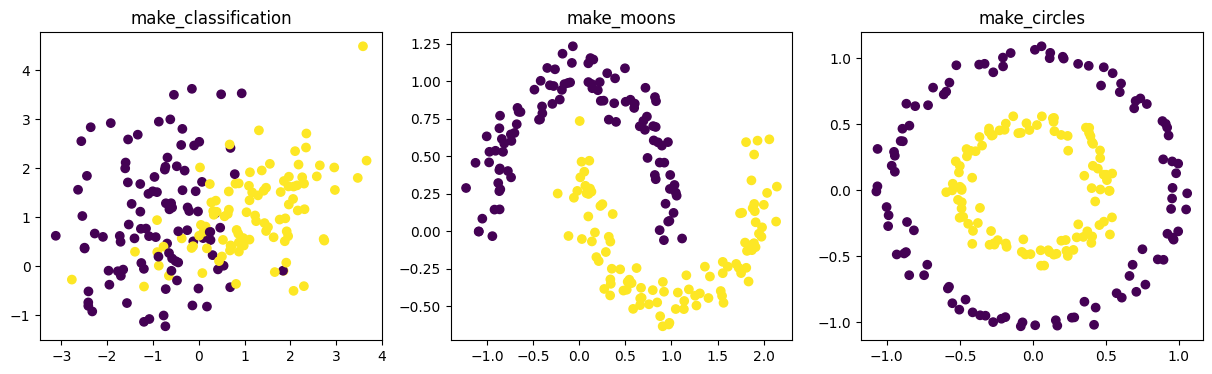

In [145]:
#linear datset
X_class, y_class = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

#moons dataset
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.1,
    random_state=42
)

#circles dataset
X_circles, y_circles = make_circles(
    n_samples=200,
    noise=0.05,
    factor=0.5,
    random_state=42
)

#visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_class[:,0], X_class[:,1], c=y_class)
axes[0].set_title("make_classification")

axes[1].scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
axes[1].set_title("make_moons")

axes[2].scatter(X_circles[:,0], X_circles[:,1], c=y_circles)
axes[2].set_title("make_circles")

plt.show()

In [146]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


## 1.2

### setosa vs versicolor

In [147]:
#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

In [148]:
#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [149]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)

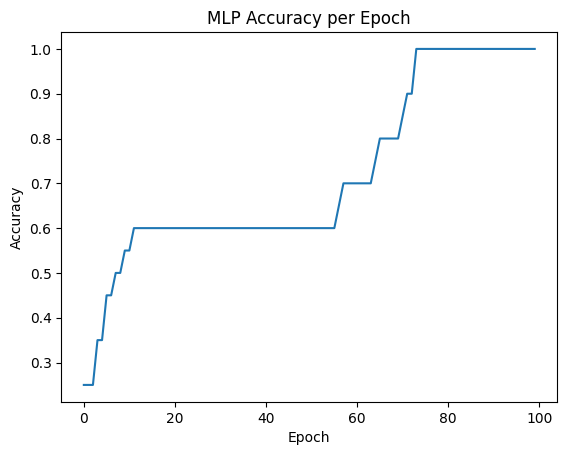

In [150]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_sv, y_train_sv)

    y_pred = model.predict(X_test_sv)
    acc = accuracy_score(y_test_sv, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### versicolor vs virginica

In [151]:
#taking two corresponding labels
mask = y >= 1

X_set_vevi = X[mask]
y_set_vevi = y[mask]

In [152]:
#splitting in training and test
X_train_vevi, X_test_vevi, y_train_vevi, y_test_vevi = train_test_split(
    X_set_vevi,
    y_set_vevi,
    test_size=0.2,
    random_state=42
)

In [153]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_vevi = scaler.fit_transform(X_train_vevi)
X_test_vevi = scaler.transform(X_test_vevi)

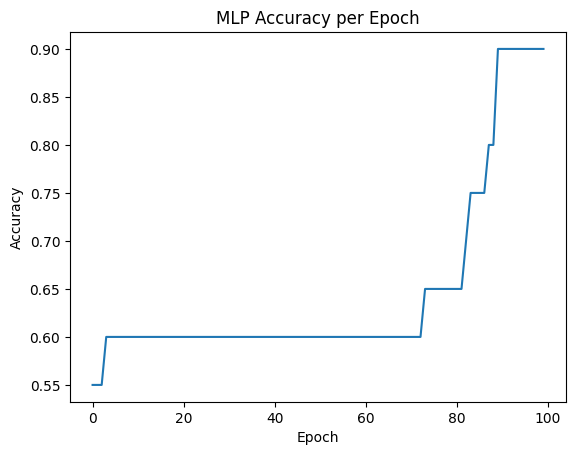

In [154]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_vevi, y_train_vevi)

    y_pred = model.predict(X_test_vevi)
    acc = accuracy_score(y_test_vevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### setosa vs virginica

In [155]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [156]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [157]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sevi = scaler.fit_transform(X_train_sevi)
X_test_sevi = scaler.transform(X_test_sevi)

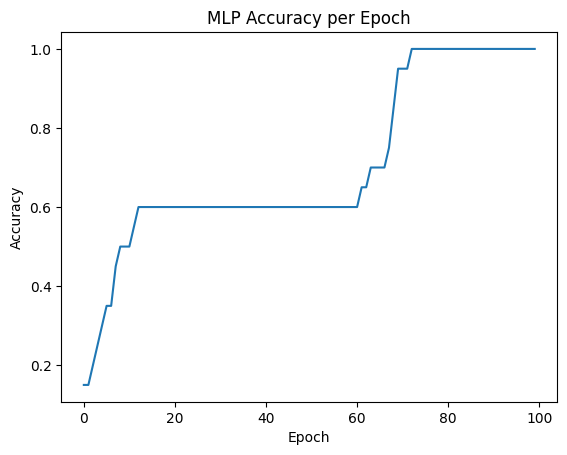

In [158]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_sevi, y_train_sevi)

    y_pred = model.predict(X_test_sevi)
    acc = accuracy_score(y_test_sevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

### one vs rest 

In [159]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [160]:
#Scaling the dataset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

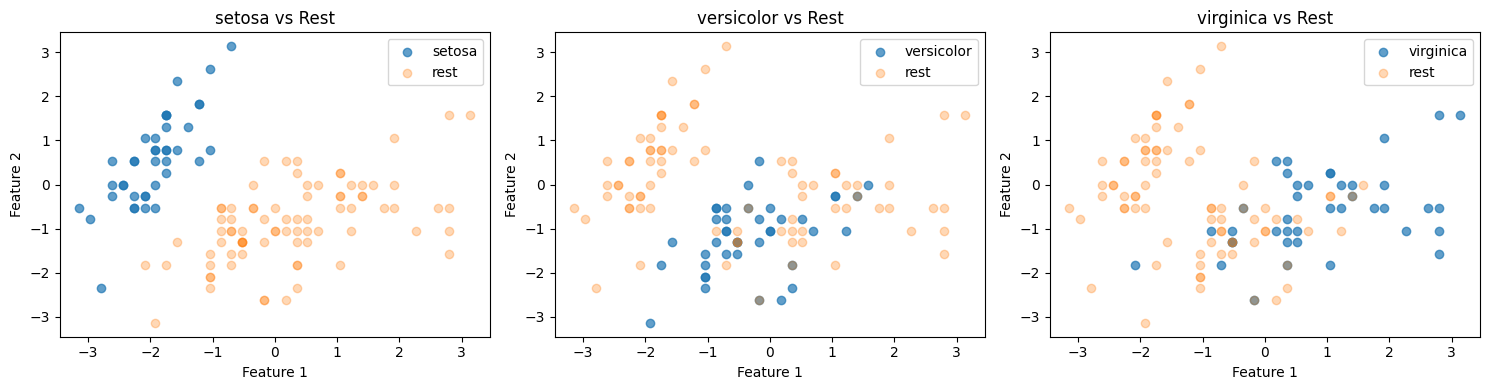

In [161]:
X_vis = X_train[:, :2]

classes = iris.target_names

plt.figure(figsize=(15, 4))

for i, c in enumerate([0, 1, 2]):

    y_bin = (y_train == c)

    plt.subplot(1, 3, i+1)

    plt.scatter(
        X_vis[y_bin, 0],
        X_vis[y_bin, 1],
        label=f"{classes[c]}",
        alpha=0.7
    )

    plt.scatter(
        X_vis[~y_bin, 0],
        X_vis[~y_bin, 1],
        label="rest",
        alpha=0.3
    )

    plt.title(f"{classes[c]} vs Rest")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()

plt.tight_layout()
plt.show()

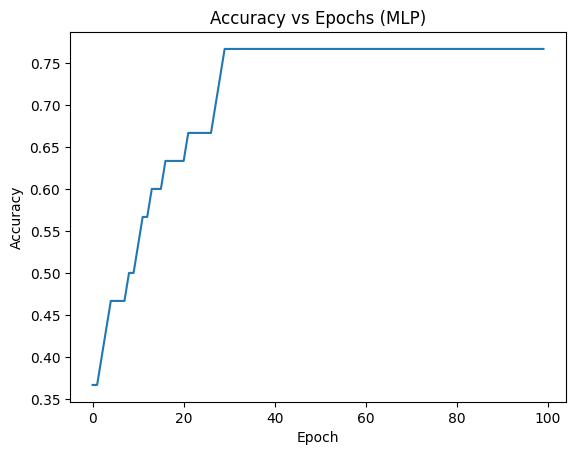

In [162]:
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,
    warm_start=True,
    random_state=42
)

epochs = 100
accuracies = []

for epoch in range(epochs):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

plt.plot(range(epochs), accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (MLP)")
plt.show()

## 1.4

The dataset is already in 4 dimensions, PCA in 4 dimensions means to just change base 

Having two feautures consents a two qubits quantum network

### e.g setosa vs virgina pca2

In [163]:
#taking two corresponding labels
mask = y!= 1

X_set_sevi = X[mask]
y_set_sevi = y[mask]

In [164]:
#splitting in training and test
X_train_sevi, X_test_sevi, y_train_sevi, y_test_sevi = train_test_split(
    X_set_sevi,
    y_set_sevi,
    test_size=0.2,
    random_state=42
)

In [165]:
#Trasforming the dataset from 4 features to 2 with pca
pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_sevi)
X_test_pca2 = pca2.transform(X_test_sevi)

In [166]:
#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_pca2 = scaler.fit_transform(X_train_pca2)
X_test_pca2 = scaler.transform(X_test_pca2)

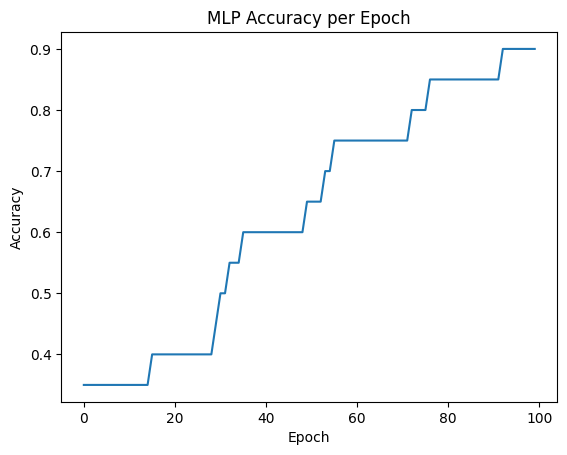

In [167]:
#classical neural network
model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1,   # training step-by-step
    warm_start=True,
    random_state=42
)
epochs = 100
accuracies = []

for i in range(epochs):
    model.fit(X_train_pca2, y_train_sevi)

    y_pred = model.predict(X_test_pca2)
    acc = accuracy_score(y_test_sevi, y_pred)

    accuracies.append(acc)
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy per Epoch")
plt.show()

# Circuit Components


## Feature Maps

In [168]:
# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc




## Ansatz

In [169]:
from qiskit.circuit.library import real_amplitudes
#RealAmplitudes doc. https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RealAmplitudes

from qiskit.circuit.library import efficient_su2 
#EfficentSU2 doc. https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.EfficientSU2

def easy_ansatz(n_bits):
    theta = ParameterVector('theta', n_bits)
    qc = QuantumCircuit(n_bits)
    
    for i in range(n_bits):
        qc.ry(theta[i], i)
        
    return qc


def Ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(N-1):
        for j in range(i+1,N):
            qc.cx(i, j)
    qc.barrier()
    for i in range(N):
        qc.ry(theta[i+N], i)
    return qc


## Interpreters


In [170]:
#-----------------------
# Parity Interpreter
# ----------------------
def parity(x):
    return "{:b}".format(x).count("1") % 2


## Builders

In [171]:
def make_sampler_qnn(feature_map_fn, ansatz_fn, N):
    circ    = feature_map_fn(N).compose(ansatz_fn(N))
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

def QNN_builder(n_bits, featureMap, ansatz, depth=1):
    fm = featureMap(n_bits)
    a = ansatz(n_bits)
    qc = QuantumCircuit(n_bits)
    for i in range(depth):
        qc = qc.compose(fm.copy())
        qc = qc.compose(a.copy())

    return qc



# Task 2

## 2.1 Creating Quantum Circuit

In [139]:
#taking two corresponding labels
mask = y < 2

X_set = X[mask]
y_set = y[mask]
scaler   = MinMaxScaler(feature_range=(-np.pi, np.pi))        
x_scaled = scaler.fit_transform(X_set)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_set, test_size=0.2, random_state=42, stratify=y_set
)

N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz(N)

### QNN

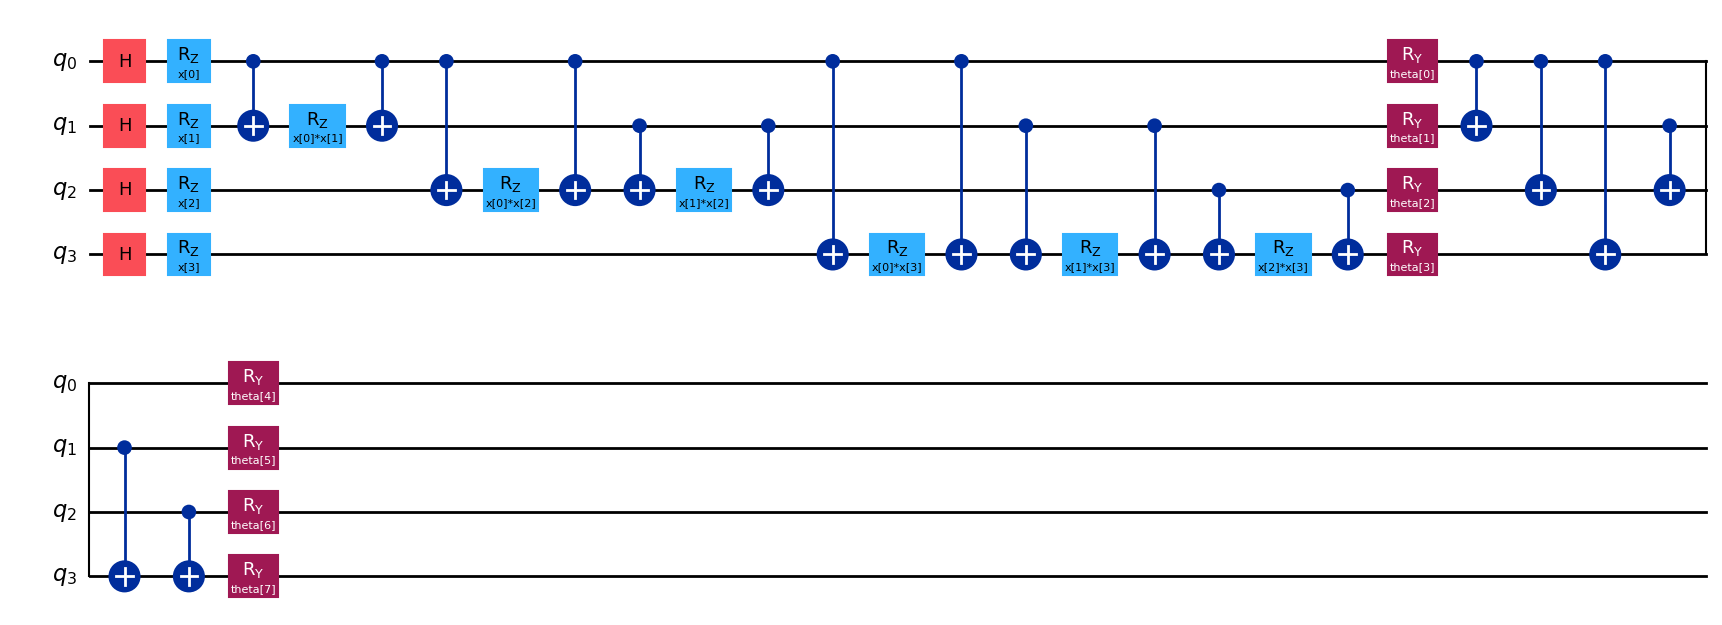

In [140]:
qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

### easy QNN

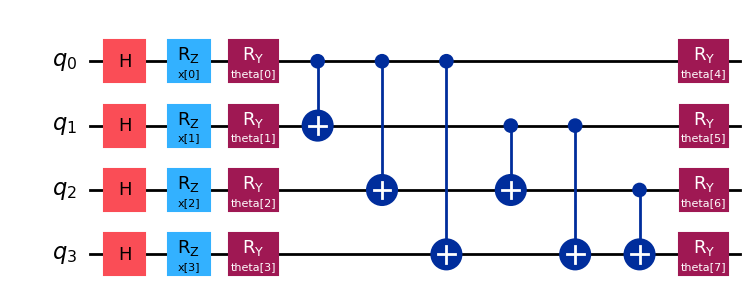

In [141]:
easy_qc = easy_feature_map.copy().compose(ansatz.copy())
easy_qc.draw("mpl", style="iqp", plot_barriers=False)

## 2.2 - SamplerQNN

In [142]:


qnn_s      = make_sampler_qnn(FeatureMap,     Ansatz, N)
qnn_s_easy = make_sampler_qnn(EasyFeatureMap, Ansatz, N)

d = qnn_s.num_weights   # number of trainable parameters = 2*N
print(f'num_inputs : {qnn_s.num_inputs}')
print(f'num_weights: {d}')


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 8


## 2.3 - Effective Dimension

In [143]:
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

# ══════════════════════════════════════════════════════════════════════
# 1. GLOBAL EFFECTIVE DIMENSION
#    - Many random weight sets → measures overall model capacity
#    - Higher ED/d → more expressive model
# ══════════════════════════════════════════════════════════════════════
global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=50, input_samples=50)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=50, input_samples=50)

global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

print(f'Global ED QNN  (n=5000): {global_eff_qnn[0]:.4f}  normalized: {global_eff_qnn[0]/d:.4f}')
print(f'Global ED easy (n=5000): {global_eff_easy[0]:.4f}  normalized: {global_eff_easy[0]/d:.4f}')

# ══════════════════════════════════════════════════════════════════════
# 2. LOCAL EFFECTIVE DIMENSION
#    - Single weight set → measures expressiveness of a specific parameterization
#    - Compare random (untrained) vs trained weights
#    - Expected: ED decreases after training (implicit regularization)
# ══════════════════════════════════════════════════════════════════════

# Random untrained weights (reproducible via algorithm_globals seed)
untrained_weights = algorithm_globals.random.uniform(0, 2 * np.pi, d)

# Trained weights: run a quick VQC fit to get a trained weight set
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap,     Ansatz, N, x_train, y_train)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz, N, x_train, y_train)

# Local ED — QNN
local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=x_train)
local_ed_untrained_qnn = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=untrained_weights,    input_samples=x_train)
# Local ED — easy QNN
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=x_train)
local_ed_untrained_easy = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=untrained_weights,    input_samples=x_train)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
local_eff_untrained_qnn  = local_ed_untrained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)
local_eff_untrained_easy = local_ed_untrained_easy.get_effective_dimension(dataset_size=n)

# ══════════════════════════════════════════════════════════════════════
# 3. FISHER INFORMATION MATRIX
#    - Extracted from run_monte_carlo() — same call used internally by ED
#    - Trace: global sensitivity to parameters (low → barren plateau)
#    - Eigenvalues: distribution of sensitivity across parameter directions
# ══════════════════════════════════════════════════════════════════════
def compute_fim(ed_obj):
    """Run MC once, return FIM averaged over input samples. Shape: (n_weights, n_weights)"""
    grads, outputs = ed_obj.run_monte_carlo()
    fim = ed_obj.get_fisher_information(grads, outputs)  # (n_samples, n_w, n_w)
    return fim.mean(axis=0)                               # (n_w, n_w)

fim_trained_qnn    = compute_fim(local_ed_trained_qnn)
fim_untrained_qnn  = compute_fim(local_ed_untrained_qnn)
fim_trained_easy   = compute_fim(local_ed_trained_easy)
fim_untrained_easy = compute_fim(local_ed_untrained_easy)

print(f'FIM trace QNN   trained: {np.trace(fim_trained_qnn):.4f}')
print(f'FIM trace QNN untrained: {np.trace(fim_untrained_qnn):.4f}')
print(f'FIM trace easy   trained: {np.trace(fim_trained_easy):.4f}')
print(f'FIM trace easy untrained: {np.trace(fim_untrained_easy):.4f}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Global ED QNN  (n=5000): 7.0650  normalized: 0.8831
Global ED easy (n=5000): 5.7656  normalized: 0.7207
Training QNN for local ED...


KeyboardInterrupt: 

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 4. PLOTS
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Row 1: Effective Dimension ────────────────────────────────
# Global ED
axes[0,0].plot(n, np.array(global_eff_qnn)  / d, marker='o', color='blue',        label='QNN')
axes[0,0].plot(n, np.array(global_eff_easy) / d, marker='s', color='forestgreen', label='easy QNN')
axes[0,0].set_xscale('log')
axes[0,0].set_ylim([0, 1])
axes[0,0].set_xlabel('Number of data samples (n)')
axes[0,0].set_ylabel('Normalized Global ED')
axes[0,0].set_title('Global Effective Dimension')
axes[0,0].legend()
axes[0,0].grid(True)

# Local ED — QNN
axes[0,1].plot(n, np.array(local_eff_trained_qnn)   / d, color='blue', marker='o', label='trained')
axes[0,1].plot(n, np.array(local_eff_untrained_qnn) / d, color='blue', marker='o', label='untrained', linestyle='--')
axes[0,1].plot(n, np.array(local_eff_trained_easy)   / d, color='forestgreen', marker='s', label='trained')
axes[0,1].plot(n, np.array(local_eff_untrained_easy) / d, color='forestgreen', marker='s', label='untrained', linestyle='--')

axes[0,1].set_xscale('log')
axes[0,1].set_ylim([0, 1])
axes[0,1].set_xlabel('Number of data samples (n)')
axes[0,1].set_ylabel('Normalized Local ED')
axes[0,1].set_title('Local ED — QNN')
axes[0,1].legend()
axes[0,1].grid(True)

# Local ED — easy QNN

axes[0,2].set_axis_off()

# ── Row 2: Fisher Information ─────────────────────────────────
# FIM heatmap — QNN trained
im0 = axes[1,0].imshow(fim_trained_qnn, cmap='viridis')
axes[1,0].set_title('FIM — QNN trained')
axes[1,0].set_xlabel('Parameter index')
axes[1,0].set_ylabel('Parameter index')
plt.colorbar(im0, ax=axes[1,0])

# FIM heatmap — easy QNN trained
im1 = axes[1,1].imshow(fim_trained_easy, cmap='viridis')
axes[1,1].set_title('FIM — easy QNN trained')
axes[1,1].set_xlabel('Parameter index')
axes[1,1].set_ylabel('Parameter index')
plt.colorbar(im1, ax=axes[1,1])

# Eigenvalue spectrum: trained vs untrained for both models
eig_trained_qnn    = np.sort(np.linalg.eigvalsh(fim_trained_qnn))[::-1]
eig_untrained_qnn  = np.sort(np.linalg.eigvalsh(fim_untrained_qnn))[::-1]
eig_trained_easy   = np.sort(np.linalg.eigvalsh(fim_trained_easy))[::-1]
eig_untrained_easy = np.sort(np.linalg.eigvalsh(fim_untrained_easy))[::-1]

x_idx = range(1, d + 1)
axes[1,2].semilogy(x_idx, eig_trained_qnn,    'o-',  color='blue',        label='QNN trained')
axes[1,2].semilogy(x_idx, eig_untrained_qnn,  'o--', color='blue',        label='QNN untrained', alpha=0.5)
axes[1,2].semilogy(x_idx, eig_trained_easy,   's-',  color='forestgreen', label='easy trained')
axes[1,2].semilogy(x_idx, eig_untrained_easy, 's--', color='forestgreen', label='easy untrained', alpha=0.5)
axes[1,2].set_xlabel('Eigenvalue index')
axes[1,2].set_ylabel('Eigenvalue (log scale)')
axes[1,2].set_title('FIM Eigenvalue Spectrum')
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

# Task 3

Task 3 - Implement quantum neural-network architectures
* Implement a modular QNN constructor in Qiskit. The constructor should accept number of qubits, feature
map type, ansatz type, ansatz depth, and output interpretation.
* Easy quantum model: ZFeatureMap plus RealAmplitudes, shallow feature-map depth.
* QNN: ZZFeatureMap or another entangling feature map plus RealAmplitudes or EfficientSU2.
* Test at least 2-qubit and 4-qubit models.
* For each architecture, report number of trainable parameters, number of input parameters, circuit depth,
and two-qubit gate count.
* Implement model outputs using SamplerQNN or EstimatorQNN. Use SamplerQNN for parity-style
classification and EstimatorQNN for expectation-value outputs if useful.

In [172]:
n_bits = [2, 4]
featureMap = [EasyFeatureMap, FeatureMap]
ansatz = [easy_ansatz, Ansatz, real_amplitudes, efficient_su2]
depth = [1, 5, 10]
quantumCircuits = {}
for n in n_bits:
    for fm in featureMap:
        for a in ansatz:
            for d in depth:
                quantumCircuits[(n, fm, a, d)] = QNN_builder(n, fm, a, depth=d)

In [173]:
samplers = {}
estimators = {}
for n in n_bits:
    for fm in featureMap:
        for a in ansatz:
            for d in depth:
                circ = quantumCircuits[(n, fm, a, d)]
                x_p = sorted([p for p in circ.parameters if p.name.startswith('x')], key=lambda p: p.name)
                theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta') or p.name.startswith('θ')], key=lambda p: p.name)            
                samplers[(n, fm, a, d)] = SamplerQNN(circuit=circ,
                                                     input_params=x_p,
                                                     weight_params=theta_p,
                                                     interpret=parity,
                                                     output_shape=2,
                                                     sampler=StatevectorSampler()) 


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler

In [174]:
for n in n_bits:
    for fm in featureMap:
        for a in ansatz:
            for d in depth:
                samp = samplers[(n, fm, a, d)]
                circ = quantumCircuits[(n, fm, a, d)]

                w = samp.num_weights
                i = samp.num_inputs
                tqc = circ.num_nonlocal_gates()
                
                fm_name = fm.__name__
                ansatz_name = a.__name__
                print("--------------------------------------------------------------------------")
                print(f"Qubits: {n} | FeatureMap: {fm_name} | Ansatz: {ansatz_name} | Depth: {d}")
                print(f"Inputs number: {i}")
                print(f"Weights number: {w}")
                print(f"Two-Qubit Gate number: {tqc}")


--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: easy_ansatz | Depth: 1
Inputs number: 2
Weights number: 2
Two-Qubit Gate number: 0
--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: easy_ansatz | Depth: 5
Inputs number: 2
Weights number: 2
Two-Qubit Gate number: 0
--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: easy_ansatz | Depth: 10
Inputs number: 2
Weights number: 2
Two-Qubit Gate number: 0
--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: Ansatz | Depth: 1
Inputs number: 2
Weights number: 4
Two-Qubit Gate number: 1
--------------------------------------------------------------------------
Qubits: 2 | FeatureMap: EasyFeatureMap | Ansatz: Ansatz | Depth: 5
Inputs number: 2
Weights number: 4

# Task 4

* Implement classical feedforward neural networks using or other libraries (PyTorch or scikit-learn).
* Use architectures with trainable-parameter counts comparable to the QNNs whenever possible.
* Report train accuracy, test accuracy, loss curves, number of parameters, and runtime.

In [175]:
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input


In [176]:
def build_model(input_lenght=4, depth=5, n_class=2):

    input_shape = (input_lenght, 1)
    
    reg = tf.keras.regularizers.l2(0)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)
    
    model = Sequential([ Dense(input_lenght, activation='relu') for d in range(depth)], Dense(n_class, activation='softmax'))
    
   
    model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Fixed here
              metrics=['accuracy'])
    
    return model
    

In [177]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU

def build_model(input_lenght=4, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [178]:

EPOCHS = 100
BATCH_SIZE = 10

accuracy = []
for _ in range(40):
    model = build_model(depth=5, n_class=3)
    fit = model.fit(X_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test, y_test),
                    verbose=False,
                    shuffle=True)
    
    accuracy.append(fit.history['val_accuracy'])

accuracy = np.array(accuracy)

/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


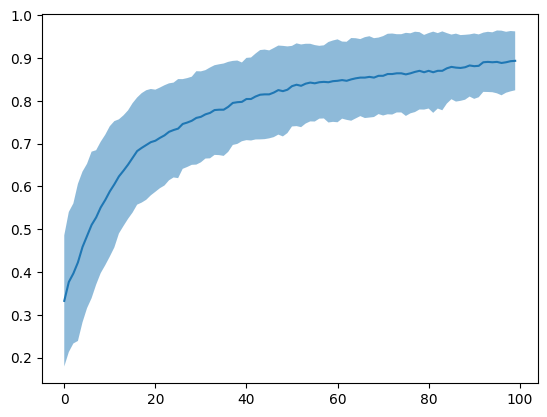

In [182]:
mean = np.mean(accuracy, axis=0)
std  = np.std(accuracy, axis=0)

plt.fill_between(range(100),mean-std, mean+std, alpha=0.5)
plt.plot(range(100),mean)


In [183]:
import pickle

with open("accuracy_classical_fnn.pkl", "wb") as f:
    pickle.dump(accuracy, f)

# Task 5

ciao, hello

# Task 6

# Task 7